In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

c:\Users\liuch\miniconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\liuch\AppData\Local\Temp\ipykernel_21564\2239167715.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Option 1 (mutually exclusive)
# Choose to run this cell if you want the plugin random forest estimator without sample splitting to be excluded from the figures.
def make_plot(depvar, n_splits, table=False, save=False):
    results = joblib.load(f'gcv_results/charitable_{depvar}_ns{n_splits}.joblib')
    results = results.reset_index().iloc[:, 1:]

    if n_splits == 1:
        results.drop(1, inplace=True)
    if depvar == 'amount':
        temp = pd.DataFrame(joblib.load(f'gcv_results/ols_results.joblib'), index=[0])
        results = pd.concat([temp, results], ignore_index=True)
    if depvar == 'gave':
        temp = pd.DataFrame(joblib.load(f'gcv_results/probit_results.joblib'), index=[0])
        results = pd.concat([temp, results], ignore_index=True)
    
    if table==True:
        print(results.to_string(index=False))

    results.reset_index(drop=True, inplace=True)
    results['halfci_width'] = results['upper'] - results['point']

    if depvar == 'amount':
        label = 'Amount donated'
    elif depvar == 'gave':
        label = 'Whether donated'

    n = results.shape[0]
    h_bracket = -0.28
    h_text = -0.46

    capsize=8
    linewidth=3
    markersize=12

    fig, ax = plt.subplots()
    ax.axhline(0, linestyle='--', color='k')

    if n_splits == 1 and depvar == 'amount':
        ax.set_xticks(range(0, n), ['OLS', 'logistic', 'sparse', 'RKHS', 'Nystrom', 'R.F.', 'N.N.'], rotation=90)

        temp = results.iloc[[0]]
        plt.errorbar(x=[0], y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='r', capsize=capsize, linewidth=linewidth, markersize=markersize)
        temp = results.iloc[[1]]
        plt.errorbar(x=[1], y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='g', capsize=capsize, linewidth=linewidth, markersize=markersize)
        temp = results.iloc[2:n]
        plt.errorbar(x=range(2, n), y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='b', capsize=capsize, linewidth=linewidth, markersize=markersize)

    elif n_splits == 5 and depvar == 'amount':
        ax.set_xticks(range(0, n), ['OLS', 'logistic', 'R.F.', 'sparse', 'RKHS', 'Nystrom', 'R.F.', 'N.N.'], rotation=90)

        temp = results.iloc[[0]]
        plt.errorbar(x=[0], y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='r', capsize=capsize, linewidth=linewidth, markersize=markersize)
        temp = results.iloc[[1, 2]]
        plt.errorbar(x=[1, 2], y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='g', capsize=capsize, linewidth=linewidth, markersize=markersize)
        temp = results.iloc[3:n]
        plt.errorbar(x=range(3, n), y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='b', capsize=capsize, linewidth=linewidth, markersize=markersize)

    elif n_splits == 1 and depvar == 'gave':
        ax.set_xticks(range(0, n), ['probit', 'logistic', 'sparse', 'RKHS', 'Nystrom', 'R.F.', 'N.N.'], rotation=90)

        temp = results.iloc[[0]]
        plt.errorbar(x=[0], y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='r', capsize=capsize, linewidth=linewidth, markersize=markersize)
        temp = results.iloc[[1]]
        plt.errorbar(x=[1], y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='g', capsize=capsize, linewidth=linewidth, markersize=markersize)
        temp = results.iloc[2:n]
        plt.errorbar(x=range(2, n), y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='b', capsize=capsize, linewidth=linewidth, markersize=markersize)

    elif n_splits == 5 and depvar == 'gave':
        ax.set_xticks(range(0, n), ['probit', 'logistic', 'R.F.', 'sparse', 'RKHS', 'Nystrom', 'R.F.', 'N.N.'], rotation=90)

        temp = results.iloc[[0]]
        plt.errorbar(x=[0], y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='r', capsize=capsize, linewidth=linewidth, markersize=markersize)
        temp = results.iloc[[1, 2]]
        plt.errorbar(x=[1, 2], y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='g', capsize=capsize, linewidth=linewidth, markersize=markersize)
        temp = results.iloc[3:n]
        plt.errorbar(x=range(3, n), y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='b', capsize=capsize, linewidth=linewidth, markersize=markersize)

    if n_splits == 1:
        ax.annotate('Prev.:\nAER', xy=(0, h_bracket), xytext=(0, h_text), xycoords=('data', 'axes fraction'), 
                    fontsize=15, ha='center', va='bottom',
                    bbox=dict(boxstyle='square', fc='white', color='w', alpha=0.0),
                    arrowprops=dict(arrowstyle='-[, widthB=0.5, lengthB=0.5', lw=2.0, color='k'))
        ax.annotate('Prev.:\nProp.', xy=(1, h_bracket), xytext=(1, h_text), xycoords=('data', 'axes fraction'), 
                    fontsize=15, ha='center', va='bottom',
                    bbox=dict(boxstyle='square', fc='white', color='w', alpha=0.0),
                    arrowprops=dict(arrowstyle='-[, widthB=0.5, lengthB=0.5', lw=2.0, color='k'))
        ax.annotate('This paper:\nAdversarial', xy=(4, h_bracket), xytext=(4, h_text), xycoords=('data', 'axes fraction'), 
                    fontsize=15, ha='center', va='bottom',
                    bbox=dict(boxstyle='square', fc='white', color='w', alpha=0.0),
                    arrowprops=dict(arrowstyle='-[, widthB=7.8, lengthB=0.5', lw=2.0, color='k'))

    elif n_splits == 5:
        ax.annotate('Prev.:\nAER', xy=(0, h_bracket), xytext=(0, h_text), xycoords=('data', 'axes fraction'), 
                    fontsize=15, ha='center', va='bottom',
                    bbox=dict(boxstyle='square', fc='white', color='w', alpha=0.0),
                    arrowprops=dict(arrowstyle='-[, widthB=0.5, lengthB=0.5', lw=2.0, color='k'))
        ax.annotate('Previous:\nProp. score', xy=(1.5, h_bracket), xytext=(1.5, h_text), xycoords=('data', 'axes fraction'), 
                    fontsize=15, ha='center', va='bottom',
                    bbox=dict(boxstyle='square', fc='white', color='w', alpha=0.0),
                    arrowprops=dict(arrowstyle='-[, widthB=2.2, lengthB=0.5', lw=2.0, color='k'))
        ax.annotate('This paper:\nAdversarial', xy=(5, h_bracket), xytext=(5, h_text), xycoords=('data', 'axes fraction'), 
                    fontsize=15, ha='center', va='bottom',
                    bbox=dict(boxstyle='square', fc='white', color='w', alpha=0.0),
                    arrowprops=dict(arrowstyle='-[, widthB=6.8, lengthB=0.5', lw=2.0, color='k'))

    if n_splits == 1:
        global ylim
        ylim = ax.get_ylim()
    if n_splits == 5:
        ax.set_ylim(ylim)

    plt.ylabel(label, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    if save == True:
        plt.savefig(f'img_noRF/charitable_{depvar}_ns{n_splits}.png', bbox_inches="tight")
    plt.show()

In [3]:
# Option 2 (mutually exclusive)
# Choose to run this cell if you want the plugin random forest estimator without sample splitting to be included in the figures.
def make_plot(depvar, n_splits, table=False, save=False):
    results = joblib.load(f'gcv_results/charitable_{depvar}_ns{n_splits}.joblib')
    results = results.reset_index().iloc[:, 1:]

    if depvar == 'amount':
        temp = pd.DataFrame(joblib.load(f'gcv_results/ols_results.joblib'), index=[0])
        results = pd.concat([temp, results], ignore_index=True)
    if depvar == 'gave':
        temp = pd.DataFrame(joblib.load(f'gcv_results/probit_results.joblib'), index=[0])
        results = pd.concat([temp, results], ignore_index=True)

    if table==True:
        print(results.to_string(index=False))

    results.reset_index(drop=True, inplace=True)
    results['halfci_width'] = results['upper'] - results['point']

    if depvar == 'amount':
        label = 'Amount donated'
    elif depvar == 'gave':
        label = 'Whether donated'

    n = results.shape[0]
    h_bracket = -0.28
    h_text = -0.46

    capsize=8
    linewidth=3
    markersize=12

    fig, ax = plt.subplots()
    ax.axhline(0, linestyle='--', color='k')

    if depvar == 'amount' and n_splits==5:
        ax.set_xticks(range(0, n), ['OLS', 'logistic', 'R.F.', 'sparse', 'RKHS', 'Nystrom', 'R.F.', 'N.N.'], rotation=90)
    elif depvar == 'amount' and n_splits==1:
        ax.set_xticks(range(0, n), ['OLS', 'logistic', '(R.F.)', 'sparse', 'RKHS', 'Nystrom', 'R.F.', 'N.N.'], rotation=90)
    elif depvar == 'gave' and n_splits==5:
        ax.set_xticks(range(0, n), ['probit', 'logistic', 'R.F.', 'sparse', 'RKHS', 'Nystrom', 'R.F.', 'N.N.'], rotation=90)
    elif depvar == 'gave' and n_splits==1:
        ax.set_xticks(range(0, n), ['probit', 'logistic', '(R.F.)', 'sparse', 'RKHS', 'Nystrom', 'R.F.', 'N.N.'], rotation=90)
    
    temp = results.iloc[[0]]
    plt.errorbar(x=[0], y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='r', capsize=capsize, linewidth=linewidth, markersize=markersize)
    if n_splits==5:
        temp = results.iloc[[1, 2]]
        plt.errorbar(x=[1, 2], y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='g', capsize=capsize, linewidth=linewidth, markersize=markersize)
    elif n_splits==1:
        temp = results.iloc[[1]]
        plt.errorbar(x=[1], y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='g', capsize=capsize, linewidth=linewidth, markersize=markersize)
        temp = results.iloc[[2]]
        eb = plt.errorbar(x=[2], y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='g', capsize=capsize, linewidth=linewidth, markersize=markersize)
        eb[-1][0].set_linestyle('--')  # Arcane code! Using fmt option above for dashed lines doesn't work.
    temp = results.iloc[3:n]
    plt.errorbar(x=range(3, n), y=temp['point'], yerr=temp['halfci_width'], fmt='.', color='b', capsize=capsize, linewidth=linewidth, markersize=markersize)

    ax.annotate('Prev.:\nAER', xy=(0, h_bracket), xytext=(0, h_text), xycoords=('data', 'axes fraction'), 
                fontsize=15, ha='center', va='bottom',
                bbox=dict(boxstyle='square', fc='white', color='w', alpha=0.0),
                arrowprops=dict(arrowstyle='-[, widthB=0.5, lengthB=0.5', lw=2.0, color='k'))
    ax.annotate('Previous:\nProp. score', xy=(1.5, h_bracket), xytext=(1.5, h_text), xycoords=('data', 'axes fraction'), 
                fontsize=15, ha='center', va='bottom',
                bbox=dict(boxstyle='square', fc='white', color='w', alpha=0.0),
                arrowprops=dict(arrowstyle='-[, widthB=2.2, lengthB=0.5', lw=2.0, color='k'))
    ax.annotate('This paper:\nAdversarial', xy=(5, h_bracket), xytext=(5, h_text), xycoords=('data', 'axes fraction'), 
                fontsize=15, ha='center', va='bottom',
                bbox=dict(boxstyle='square', fc='white', color='w', alpha=0.0),
                arrowprops=dict(arrowstyle='-[, widthB=6.8, lengthB=0.5', lw=2.0, color='k'))

    if n_splits == 1:
        global ylim
        ylim = ax.get_ylim()
    if n_splits == 5:
        ax.set_ylim(ylim)

    plt.ylabel(label, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    if save == True:
        plt.savefig(f'img/charitable_{depvar}_ns{n_splits}.png', bbox_inches="tight")
    plt.show()

In [4]:
table = True  # Display a plain table of the values of the estimates?
save = False  # Save the figures?

   point   stderr     lower    upper
0.117730 0.268693 -0.408899 0.644358
0.414436 0.349158 -0.269940 1.098812
0.165361 0.141069 -0.111144 0.441865
0.363893 0.198812 -0.025793 0.753579
0.122943 0.125475 -0.122997 0.368884
0.109084 0.117471 -0.121167 0.339335
0.070641 0.181921 -0.285937 0.427220
0.343250 0.246031 -0.138989 0.825488


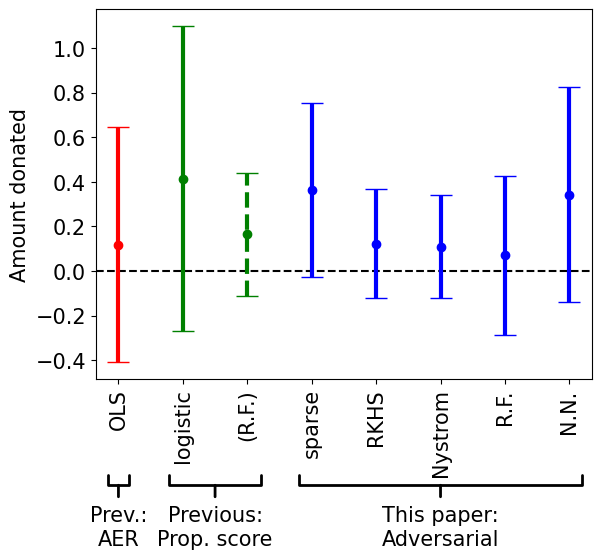

   point   stderr     lower    upper
0.117730 0.268693 -0.408899 0.644358
0.397850 0.350178 -0.288525 1.084224
0.160289 0.150120 -0.133956 0.454534
0.360927 0.198972 -0.029072 0.750926
0.129831 0.128671 -0.122373 0.382035
0.112821 0.119604 -0.121610 0.347253
0.090360 0.181980 -0.266334 0.447054
0.368600 0.219325 -0.061293 0.798492


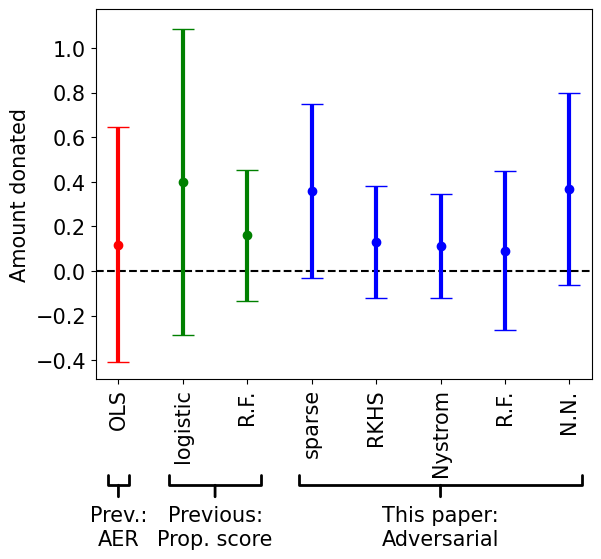

In [5]:
# Heterogeneous effects on dollars donated {n = 25859, dim(W) = 15}
make_plot('amount', 1, table=table, save=save)  # No sample splitting
make_plot('amount', 5, table=table, save=save)  # Sample splitting
# Note: the formatting code uses the y-axis of the no sample splitting plot for both plots, so the no sample splitting plot should be created first.

   point   stderr     lower    upper
0.004267 0.004123 -0.003815 0.012348
0.009120 0.004984 -0.000650 0.018889
0.002676 0.002284 -0.001800 0.007152
0.005517 0.002892 -0.000151 0.011184
0.003889 0.001939  0.000088 0.007689
0.004024 0.001920  0.000261 0.007788
0.000048 0.002941 -0.005716 0.005812
0.004466 0.003197 -0.001801 0.010733


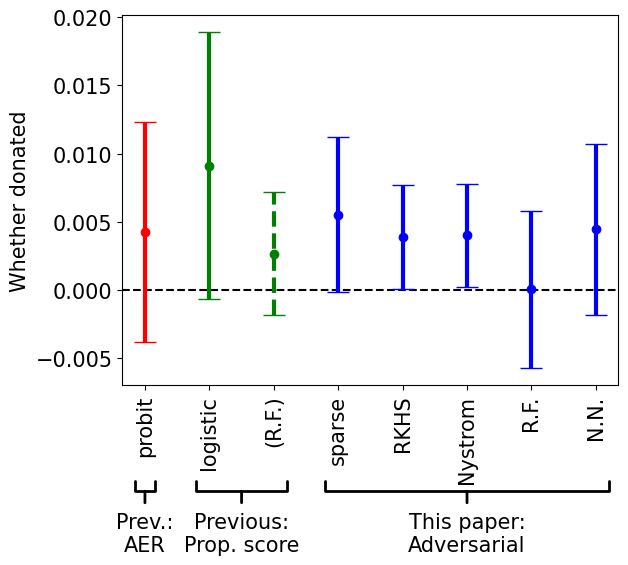

   point   stderr     lower    upper
0.004267 0.004123 -0.003815 0.012348
0.008975 0.005030 -0.000884 0.018834
0.002550 0.002472 -0.002295 0.007396
0.005434 0.002902 -0.000254 0.011122
0.004019 0.001969  0.000159 0.007879
0.003967 0.001926  0.000191 0.007743
0.000734 0.002922 -0.004994 0.006462
0.004931 0.003088 -0.001121 0.010983


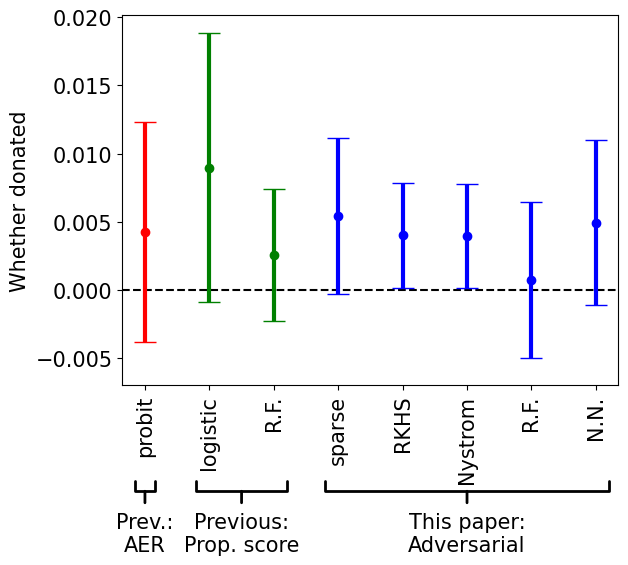

In [6]:
# Heterogeneous effects on whether donated {n = 25859, dim(W) = 15}
make_plot('gave', 1, table=table, save=save)  # No sample splitting
make_plot('gave', 5, table=table, save=save)  # Sample splitting
# Note: the formatting code uses the y-axis of the no sample splitting plot for both plots, so the no sample splitting plot should be created first.